# Measure nearest neighbor instrinsic dimension (NNID) of jets with Omnifold measurement

**TODO** add some description of what is happening in this notebook and disclaimer about it taking forever to run without good resources

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import glob
import pickle
import numpy as np
import awkward as ak
import uproot
import pandas as pd
import fastjet as fj

import utils
import visualize as vis

In [12]:
# Get ROOT TTrees and pass 190 flags
f = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_May19_MGPy8FxFxPlusNonStrong_withdd_Test_23Nov25_shuffled.root"
)
t = f["OmniTree"]
truth_pass190 = ak.to_numpy(t["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

f_pd = uproot.open(
    "/pscratch/sd/k/kgreif/data/TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_shuffled.root"
)
t_pd = f_pd["OmniTree"]
truth_pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())
truth_pT_ll_pd = ak.to_numpy(t_pd["truth_pT_ll"].array())
truth_pass200_pd = np.logical_and(truth_pass190_pd, truth_pT_ll_pd > 200)

f_hv = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5_shuffled.root"
)
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190_hv, truth_pT_ll_hv > 200)

f_sherpa = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_30Jul2025_Sherpa2211PlusNonStrong_8Dec25_shuffled.root"
)
t_sherpa = f_sherpa["OmniTree"]
truth_pass190_sherpa = ak.to_numpy(t_sherpa["truth_pass190"].array())
truth_pT_ll_sherpa = ak.to_numpy(t_sherpa["truth_pT_ll"].array())
truth_pass200_sherpa = np.logical_and(truth_pass190_sherpa, truth_pT_ll_sherpa > 200)

In [13]:
# Load event weights for the Sherpa and MadGraph predictions
mg_weights = np.load("/pscratch/sd/k/kgreif/zjets_plot_staging/madgraph_weights.npz")
sherpa_weights = np.load("/pscratch/sd/k/kgreif/zjets_plot_staging/sherpa_weights.npz")

## Measurement with Pseudodata

Note we assume all EMDs have been calculated. Run the `calc_correlation_dimension.ipynb` notebook to do this

### Calculation

In [14]:
# Load all weights from the Omnifold pseudodata measurement
of_pseudodata = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="weights",
    mode="r",
)
of_pseudodata_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="hv_weights",
    mode="r",
)

In [15]:
# Create dictionary describing all of the histograms needed for the pseudodata measurement
n_init_weights = [name for name in of_pseudodata.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_mc_" in name]
truth_mc_weights = {
    "prior": mg_weights["nominal"][truth_pass200 == 1],
    "nominal": of_pseudodata["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": of_pseudodata["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_pseudodata["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_pseudodata["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_pseudodata["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_pseudodata["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_pseudodata["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_pseudodata["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_pseudodata["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_pseudodata["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_pseudodata["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_pseudodata["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_pseudodata["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_pseudodata["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_pseudodata["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_pseudodata["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_pseudodata["target_dd"].to_numpy()[truth_pass200 == 1],
}
truth_pd_weights = {
    "truthpd": ak.to_numpy(t_pd["weight_mc"].array())[truth_pass200_pd == 1],
}
hv_weights = {
    "hv": of_pseudodata_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}

In [16]:
# Load all EMDs needed for the pseudodata measurement
truth_mc_emds = "./emd_storage/truth_mc_330to370.npz"
truth_pd_emds = "./emd_storage/truth_pd_330to370.npz"
truth_hv_emds = "./emd_storage/truth_hv_330to370.npz"

truth_mc_emds_zip = np.load(truth_mc_emds)
truth_pd_emds_zip = np.load(truth_pd_emds)
truth_hv_emds_zip = np.load(truth_hv_emds)

truth_mc_emds = truth_mc_emds_zip["emds"]
truth_mc_evt_idx = truth_mc_emds_zip["event_indices"]
truth_pd_emds = truth_pd_emds_zip["emds"]
truth_pd_evt_idx = truth_pd_emds_zip["event_indices"]
truth_hv_emds = truth_hv_emds_zip["emds"]
truth_hv_evt_idx = truth_hv_emds_zip["event_indices"]

In [17]:
# Slice appropriate weights from the weights dictionary
sliced_truth_mc_weights = {key: value[truth_mc_evt_idx] for key, value in truth_mc_weights.items()}
sliced_truth_pd_weights = {key: value[truth_pd_evt_idx] for key, value in truth_pd_weights.items()}
sliced_hv_weights = {key: value[truth_hv_evt_idx] for key, value in hv_weights.items()}

In [18]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
truth_mc_emds = utils.sort_emd_matrix(truth_mc_emds)
truth_pd_emds = utils.sort_emd_matrix(truth_pd_emds)
truth_hv_emds = utils.sort_emd_matrix(truth_hv_emds)

Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)


In [19]:
# Now calculate the NNID estimator for all values if i and all weight sets
# This involves a numerical minimization of the likelihood at each point and for each weight set
points = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
truth_mc_results = utils.calculate_nnids_from_sorted_emds(truth_mc_emds, sliced_truth_mc_weights, points)
truth_pd_results = utils.calculate_nnids_from_sorted_emds(truth_pd_emds, sliced_truth_pd_weights, points)
truth_hv_results = utils.calculate_nnids_from_sorted_emds(truth_hv_emds, sliced_hv_weights, points)

Processing 153 weight sets for 86 points...


Processing weight sets: 100%|██████████| 153/153 [05:42<00:00,  2.24s/set]


Processing 1 weight sets for 86 points...


Processing weight sets: 100%|██████████| 1/1 [00:02<00:00,  2.15s/set]


Processing 1 weight sets for 86 points...


Processing weight sets: 100%|██████████| 1/1 [00:02<00:00,  2.13s/set]


In [22]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "pd_mc_results_330to370.npz"), **truth_mc_results)
np.savez(os.path.join(save_dir, "truth_pd_results_330to370.npz"), **truth_pd_results)
np.savez(os.path.join(save_dir, "pd_hv_results_330to370.npz"), **truth_hv_results)

### Plotting

In [3]:
# Load results from .npz files
save_dir = "./nnid_storage"
truth_mc_results_zip = np.load(os.path.join(save_dir, "pd_mc_results_330to370.npz"))
truth_mc_results = {key: truth_mc_results_zip[key] for key in truth_mc_results_zip.files}
truth_pd_results_zip = np.load(os.path.join(save_dir, "truth_pd_results_330to370.npz"))
truth_pd_results = {key: truth_pd_results_zip[key] for key in truth_pd_results_zip.files}
truth_hv_results_zip = np.load(os.path.join(save_dir, "pd_hv_results_330to370.npz"))
truth_hv_results = {key: truth_hv_results_zip[key] for key in truth_hv_results_zip.files}

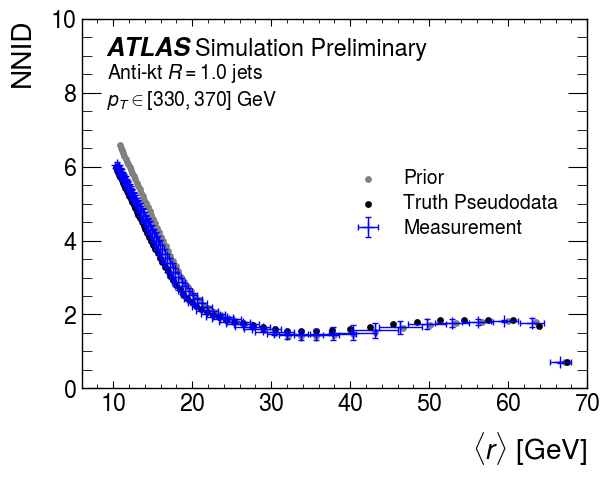

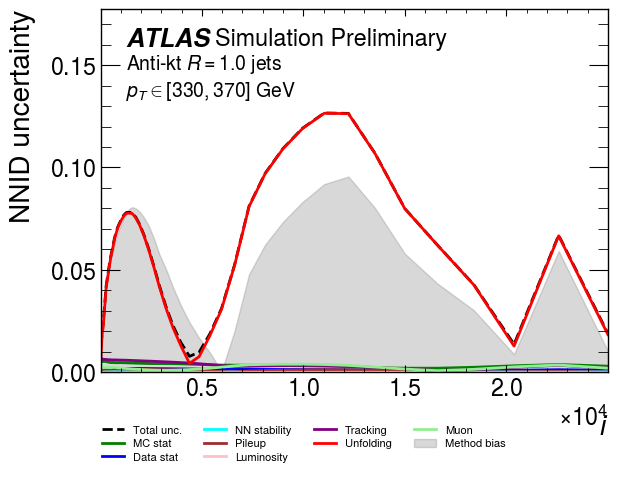

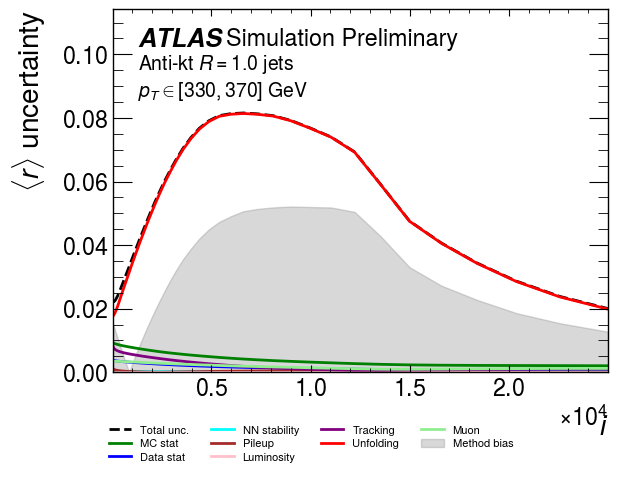

In [29]:
# Plot comparison to truth pseudodata
import visualize as vis
pd_plot, uc_nnid, uc_avgr = vis.plot_nnid_pseudodata(
    mc_results=truth_mc_results,
    pd_results=truth_pd_results,
    hv_results=truth_hv_results,
    low_limit=22,
    high_limit=100,
    point_indices=points,
    plot_uncertainty_budget=True,
)
pd_plot.show()
uc_nnid.show()
uc_avgr.show()

## Measurement with data

### Calculation

In [30]:
# Load all weights from the Omnifold data measurement
of_data = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="weights",
    mode="r",
)
of_data_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="hv_weights",
    mode="r",
)

In [31]:
# Create dictionary describing all of the histograms needed for the data measurement
n_init_weights = [name for name in of_data.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_data.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in of_data.keys() if "weights_bootstrap_mc_" in name]
truth_mc_weights = {
    "nominal": of_data["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": of_data[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_data[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": of_data[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": of_data["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_data["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_data["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_data["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_data["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_data["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_data["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_data["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_data["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_data["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_data["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_data["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_data["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_data["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_data["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_data["target_dd"].to_numpy()[truth_pass200 == 1],
}
hv_weights = {
    "hv": of_data_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}
truth_madgraph_weights = {
    "madgraph": mg_weights["nominal"][truth_pass200 == 1],
    "weights_theoryQCD": mg_weights["weights_theoryQCD"][truth_pass200 == 1],
    "weights_theoryPDF": mg_weights["weights_theoryPDF"][truth_pass200 == 1],
    "weights_theoryAlphaS": mg_weights["weights_theoryAlphaS"][truth_pass200 == 1],
    "weights_theoryPSsoft": mg_weights["weights_theoryPSsoft"][truth_pass200 == 1],
    "weights_theoryPSjet": mg_weights["weights_theoryPSjet"][truth_pass200 == 1],
    "weights_theoryPSscale": mg_weights["weights_theoryPSscale"][truth_pass200 == 1],
    "weights_theoryMPI": mg_weights["weights_theoryMPI"][truth_pass200 == 1],
}
truth_sherpa_weights = {
    "sherpa": sherpa_weights["nominal"][truth_pass200_sherpa == 1],
    "weights_theoryQCD": sherpa_weights["weights_theoryQCD"][truth_pass200_sherpa == 1],
    "weights_theoryPDF": sherpa_weights["weights_theoryPDF"][truth_pass200_sherpa == 1],
    "weights_theoryAlphaS": sherpa_weights["weights_theoryAlphaS"][truth_pass200_sherpa == 1],
}

In [32]:
# Load all EMDs needed for the data measurement
truth_mc_emds = "./emd_storage/truth_mc_330to370.npz"
truth_sherpa_emds = "./emd_storage/truth_sherpa_330to370.npz"
truth_hv_emds = "./emd_storage/truth_hv_330to370.npz"

truth_mc_emds_zip = np.load(truth_mc_emds)
truth_sherpa_emds_zip = np.load(truth_sherpa_emds)
truth_hv_emds_zip = np.load(truth_hv_emds)

truth_mc_emds = truth_mc_emds_zip["emds"]
truth_mc_evt_idx = truth_mc_emds_zip["event_indices"]
truth_sherpa_emds = truth_sherpa_emds_zip["emds"]
truth_sherpa_evt_idx = truth_sherpa_emds_zip["event_indices"]
truth_hv_emds = truth_hv_emds_zip["emds"]
truth_hv_evt_idx = truth_hv_emds_zip["event_indices"]

In [33]:
# Slice appropriate weights from the weights dictionary
sliced_truth_mc_weights = {
    key: value[truth_mc_evt_idx] for key, value in truth_mc_weights.items()
}
sliced_truth_madgraph_weights = {
    key: value[truth_mc_evt_idx] for key, value in truth_madgraph_weights.items()
}
sliced_truth_sherpa_weights = {
    key: value[truth_sherpa_evt_idx] for key, value in truth_sherpa_weights.items()
}
sliced_hv_weights = {key: value[truth_hv_evt_idx] for key, value in hv_weights.items()}

In [34]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
truth_mc_emds = utils.sort_emd_matrix(truth_mc_emds)
truth_sherpa_emds = utils.sort_emd_matrix(truth_sherpa_emds)
truth_hv_emds = utils.sort_emd_matrix(truth_hv_emds)

Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)


In [35]:
# Now calculate the NNID estimator for all values if i and all weight sets
# This involves a numerical minimization of the likelihood at each point and for each weight set
points = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
truth_mc_results = utils.calculate_nnids_from_sorted_emds(
    truth_mc_emds, sliced_truth_mc_weights, points
)
truth_madgraph_results = utils.calculate_nnids_from_sorted_emds(
    truth_mc_emds, sliced_truth_madgraph_weights, points
)
truth_sherpa_results = utils.calculate_nnids_from_sorted_emds(
    truth_sherpa_emds, sliced_truth_sherpa_weights, points
)
truth_hv_results = utils.calculate_nnids_from_sorted_emds(
    truth_hv_emds, sliced_hv_weights, points
)

Processing 152 weight sets for 86 points...


Processing weight sets: 100%|██████████| 152/152 [05:33<00:00,  2.19s/set]


Processing 8 weight sets for 86 points...


Processing weight sets: 100%|██████████| 8/8 [00:17<00:00,  2.25s/set]


Processing 4 weight sets for 86 points...


Processing weight sets: 100%|██████████| 4/4 [00:08<00:00,  2.09s/set]


Processing 1 weight sets for 86 points...


Processing weight sets: 100%|██████████| 1/1 [00:02<00:00,  2.12s/set]


In [36]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "data_mc_results_330to370.npz"), **truth_mc_results)
np.savez(os.path.join(save_dir, "data_hv_results_330to370.npz"), **truth_hv_results)
np.savez(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"), **truth_madgraph_results)
np.savez(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"), **truth_sherpa_results)

### Plotting

In [37]:
# Load results from .npz files
save_dir = "./nnid_storage"
truth_mc_results_zip = np.load(os.path.join(save_dir, "data_mc_results_330to370.npz"))
truth_mc_results = {key: truth_mc_results_zip[key] for key in truth_mc_results_zip.files}
truth_hv_results_zip = np.load(os.path.join(save_dir, "data_hv_results_330to370.npz"))
truth_hv_results = {key: truth_hv_results_zip[key] for key in truth_hv_results_zip.files}
truth_madgraph_results_zip = np.load(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"))
truth_madgraph_results = {key: truth_madgraph_results_zip[key] for key in truth_madgraph_results_zip.files}
truth_sherpa_results_zip = np.load(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"))
truth_sherpa_results = {key: truth_sherpa_results_zip[key] for key in truth_sherpa_results_zip.files}

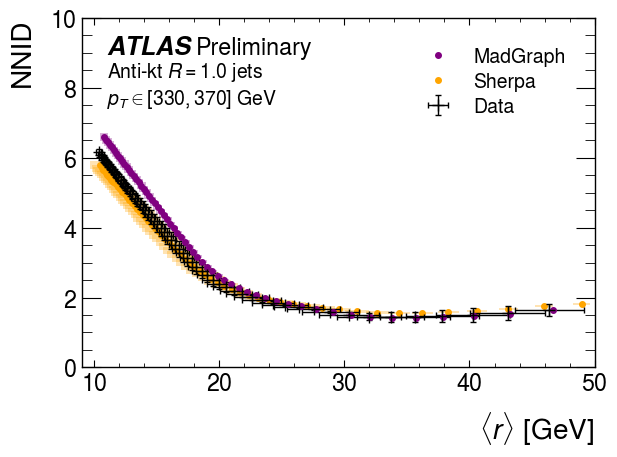

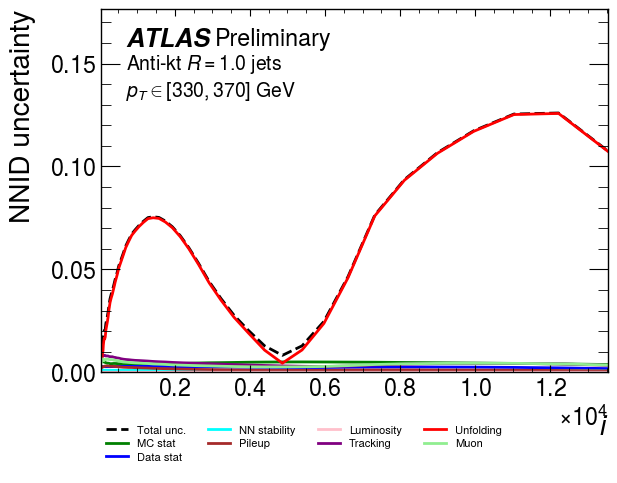

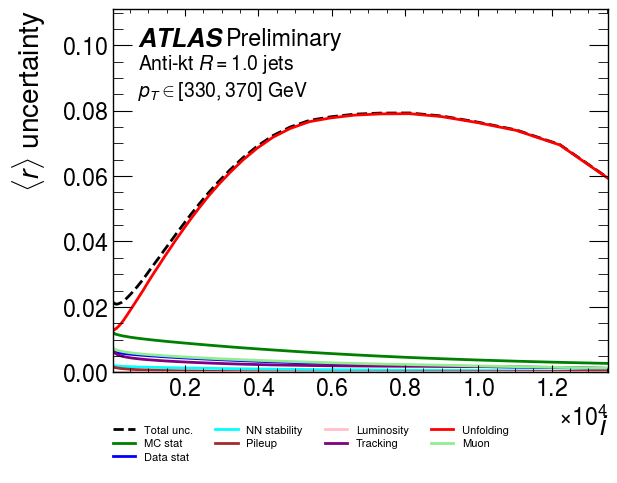

In [61]:
import visualize as vis
data_plot, uc_nnid, uc_avgr = vis.plot_nnid_data(
    mc_results=truth_mc_results,
    hv_results=truth_hv_results,
    madgraph_results=truth_madgraph_results,
    sherpa_results=truth_sherpa_results,
    low_limit=22,
    high_limit=80,
    point_indices=points,
    plot_uncertainty_budget=True,
    xlim=(9, 50),
)
data_plot.show()
uc_nnid.show()
uc_avgr.show()